# HOMEWORK 13

In this homework you are going to build your first classifier for the CIFAR-10 dataset. This dataset contains 10 different classes and you can learn more about it [here](https://www.cs.toronto.edu/~kriz/cifar.html). This homework consists of the following tasks:
* Dataset inspection
* Building the network
* Training
* Evaluation

At the end, as usual, there will be a couple of questions for you to answer :-)

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D, BatchNormalization
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Step 0: Dataset Inspection

Load the dataset and make a quick inspection.

C:\Users\PC\AppData\Local\Temp\ipykernel_10844\2401666654.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(classes[int(y_train[idx])])


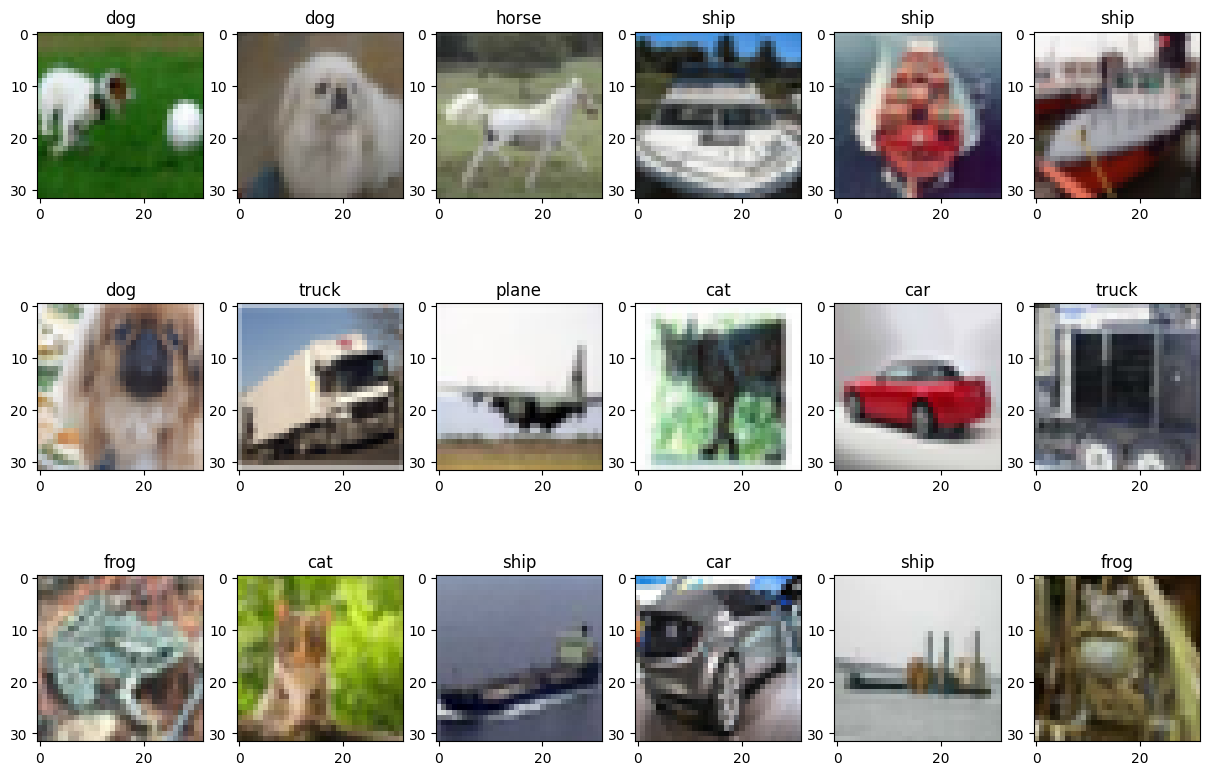

In [3]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):    
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    idx = np.random.randint(0, len(x_train))
    # Show the image and the label
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx])])

Compute the class histogram (you can visualize it if you want). Is the dataset balanced?

Hint: You might find [Counter](https://docs.python.org/3/library/collections.html#collections.Counter) tool useful. In any case, it's up to you how you compute the histogram.

In [4]:
y = np.concatenate((y_train, y_test), axis=0)

(Text(0.5, 0, 'Class ID'), Text(0, 0.5, 'Counts'))

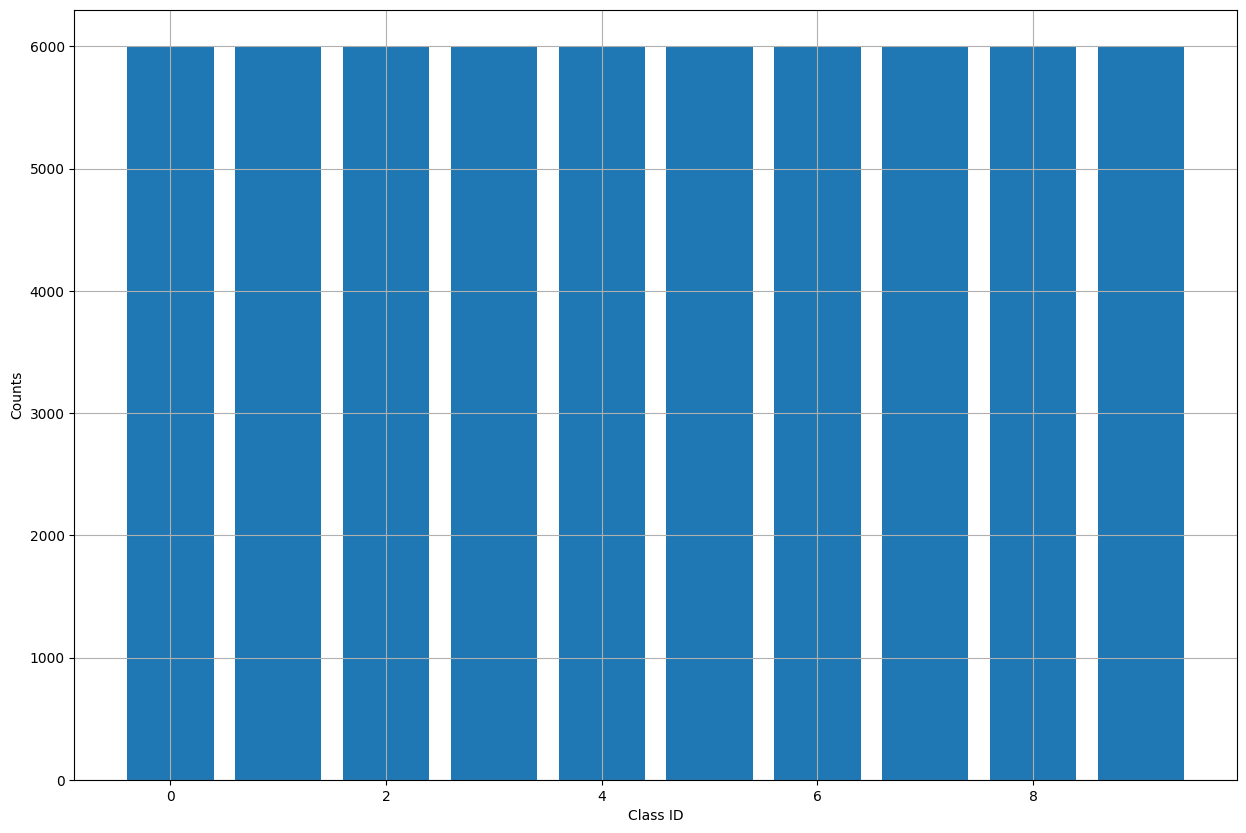

In [5]:
unique, counts = np.unique(y, return_counts=True)

plt.bar(unique, counts), plt.grid(True)
plt.xlabel('Class ID'), plt.ylabel('Counts')

The dataset is balanced, as the frequency of each class is the same.

### Step 1: Data Preparation

In this step, you'll need to prepare the data for training, i.e., you will have to normalize it and encode the labels as one-hot vectors.

In [6]:
# Normalization
x_train = x_train/255
x_test = x_test/255

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


### Step 2: Building the Classifier

Build the CNN for CIFAR10 classification. For starters, you can use the same network we used in the lesson for the MNIST problem.

In [7]:
inputs = Input(shape=(size, size, 3))

net = Conv2D(16, kernel_size=(3, 3), activation="relu")(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(32, kernel_size=(3, 3), activation="relu")(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Flatten()(net)
outputs = Dense(num_classes, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 30, 30, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          11,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,618 (64.91 KB)

 Trainable params: 16,618 (64.91 KB)

 Non-trainable params: 0 (0.00 B)

### Step 3: Training

Compile the model and train it.

In [8]:
epochs = 25
batch_size = 128

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.3101 - loss: 1.9211 - val_accuracy: 0.4498 - val_loss: 1.5934
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.4930 - loss: 1.4447 - val_accuracy: 0.5048 - val_loss: 1.4291
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5338 - loss: 1.3318 - val_accuracy: 0.5400 - val_loss: 1.3106
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.5621 - loss: 1.2585 - val_accuracy: 0.5668 - val_loss: 1.2360
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.5820 - loss: 1.2043 - val_accuracy: 0.5854 - val_loss: 1.1880
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.5976 - loss: 1.1604 - val_accuracy: 0.6064 - val_loss: 1.1469
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.6114 - loss: 1.1237 - val_accuracy: 0.6170 - val_loss: 1.1182
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.6212 - loss: 1.0919 - 

Train Acc      0.7052444219589233
Validation Acc 0.6682000160217285


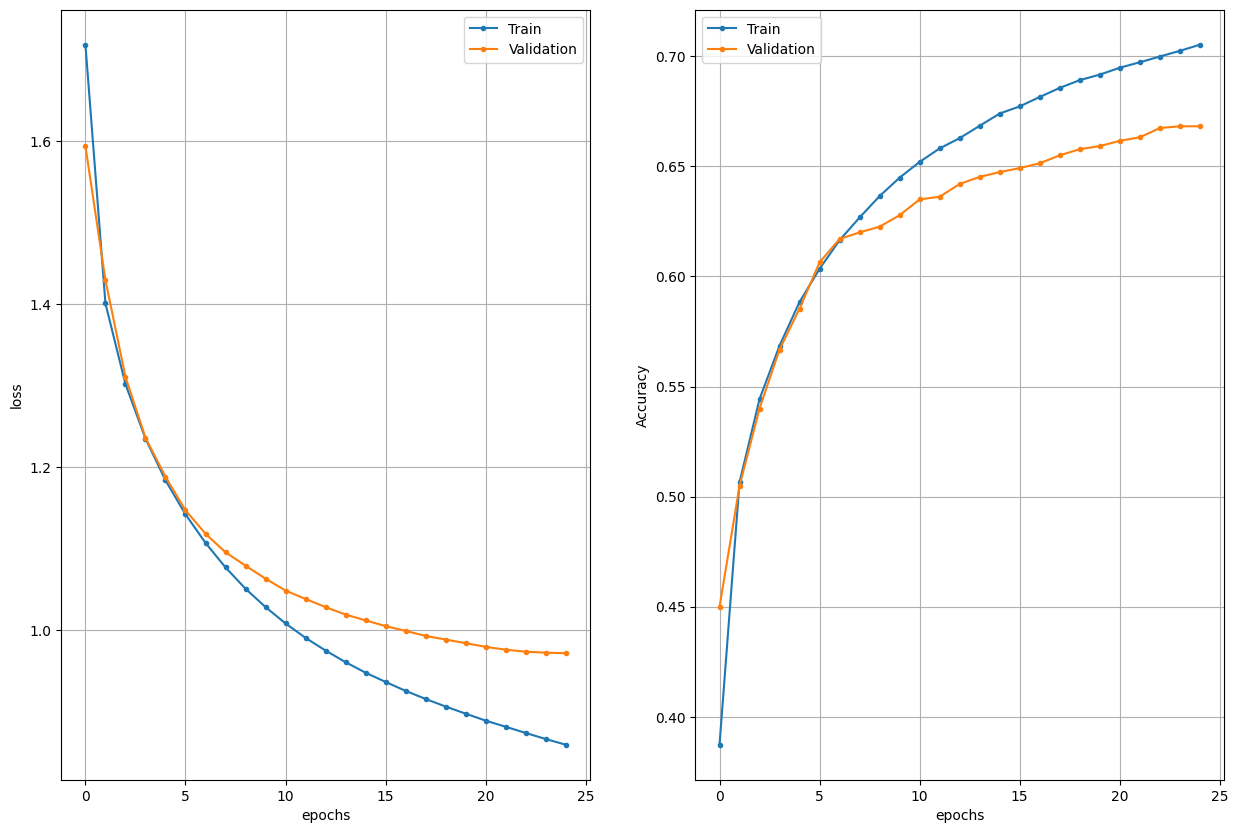

In [9]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])    

### Step 4: Evaluation

In this step, you have to calculate the accuracies and visualize some random samples. For the evaluation, you are going to use the test split from the dataset.

In [10]:
# Compute the labels and the predictions as sparse values
y_true = np.argmax(y_test, axis=1)
y_pred = model.predict(x_test)

print('True', y_true[0:5])
print('Pred', np.argmax(y_pred[0:5, :], axis=1))
print('Pred', y_pred[0:5, :])
print(y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
True [3 8 8 0 6]
Pred [3 8 8 0 6]
Pred [[1.76124752e-03 3.65274784e-04 2.60373931e-02 8.10862660e-01
  3.65967862e-02 4.20995653e-02 3.96704227e-02 2.55398161e-04
  3.85415293e-02 3.80972237e-03]
 [1.54571254e-02 2.14026019e-01 8.07111246e-06 5.39154144e-07
  2.27922942e-06 1.10521468e-08 3.50563001e-09 4.13129010e-06
  7.54726827e-01 1.57750584e-02]
 [1.11822672e-01 2.52484560e-01 1.41799683e-03 1.13765905e-02
  1.25237303e-02 5.89029223e-04 8.83336528e-04 5.82745858e-03
  4.17392612e-01 1.85682014e-01]
 [8.15526128e-01 6.33322820e-02 9.24501382e-03 1.87063206e-03
  8.17768741e-03 3.63292609e-04 2.60638044e-04 1.89974054e-03
  9.67875347e-02 2.53701024e-03]
 [2.40000986e-06 2.18628658e-04 1.03844106e-02 2.44323704e-02
  1.56635791e-01 5.54813957e-03 8.01787257e-01 6.77504213e-05
  8.48205411e-04 7.48968232e-05]]
(10000, 10)


In [11]:
# Compute and print the accuracy for each class

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

for class_id, class_name in classes.items():
    idxs = np.where(y_true_classes == class_id)[0]
    acc = np.mean(y_pred_classes[idxs] == y_true_classes[idxs])
    print(class_name, acc)


plane 0.701
car 0.759
bird 0.541
cat 0.429
deer 0.687
dog 0.553
frog 0.822
horse 0.681
ship 0.687
truck 0.783


In [12]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6676 - loss: 0.9761
Test loss   0.9831304550170898
Test metric 0.6643000245094299


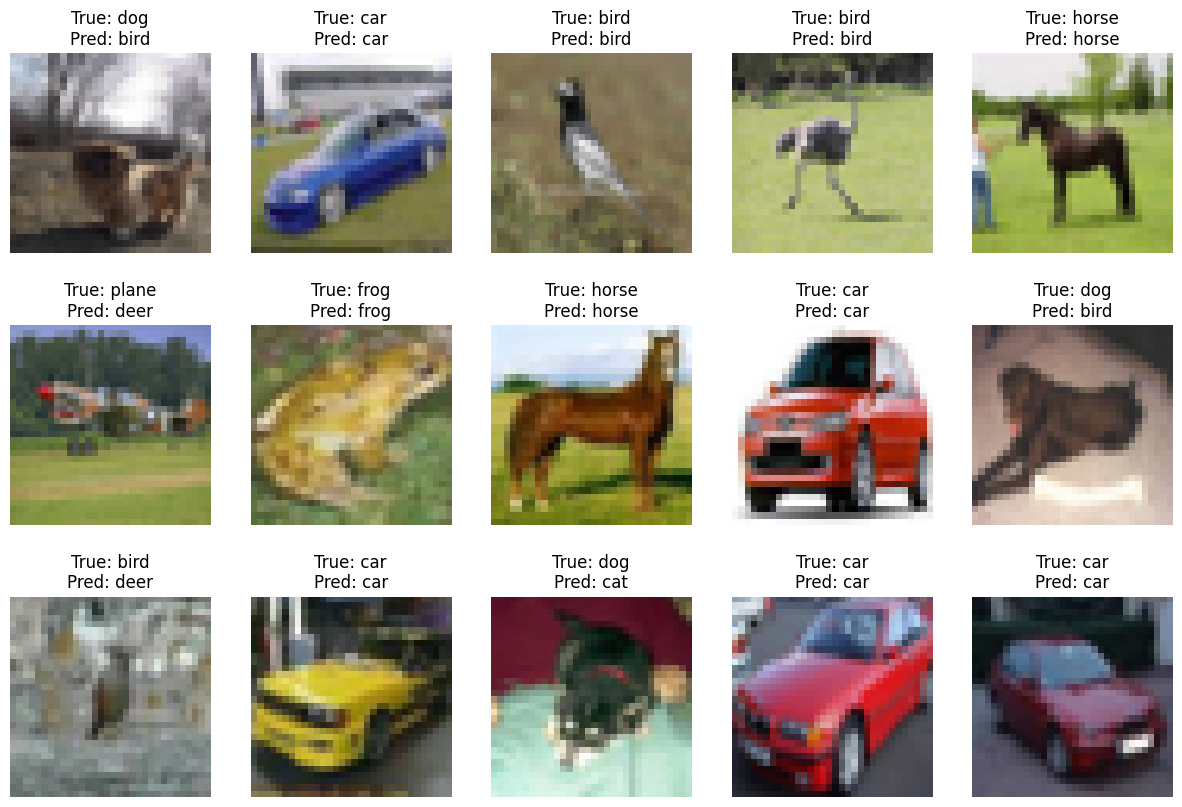

In [13]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = np.random.randint(0, len(x_test))
    # Show the results
    plt.subplot(3,5,ii+1)
    plt.imshow(x_test[idx, ...])
    plt.axis('off')
    plt.title(f"True: {classes[y_true_classes[idx]]}\nPred: {classes[y_pred_classes[idx]]}")

### Questions

#### What is the overall accuracy of the classifier?
The overall accuracy of the classifier is about 66.43% on the test set.

#### What modifications would you do in order to improve the classification accuracy?
We could try to improve accuracy by adding more layers or filters, applying dropout or batch normalization, and training for more epochs with learning rate adjustments.

#### Make **one** modification (that you think can help) and train the classifier again. Does the accuracy improve?
I tried to make only one modification, such as adding batch normalization, but the accuracy didn't improve. Therefore, I did slightly more modifications: added one more convolutional layer, added dropout, and adjusted size of the convolutional layers. The accuracy improved to 73.61% on test dataset. The results are shown below.

In [14]:
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D, Dropout
from tensorflow.keras import Model

inputs = Input(shape=(size, size, 3))

net = Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
net = MaxPooling2D((2,2))(net)

net = Conv2D(64, (3,3), activation="relu", padding="same")(net)
net = MaxPooling2D((2,2))(net)

net = Conv2D(128, (3,3), activation="relu", padding="same")(net)
net = MaxPooling2D((2,2))(net)

net = Flatten()(net)
net = Dropout(0.2)(net)
outputs = Dense(num_classes, activation="softmax")(net)

model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │          20,490 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 113,738 (444.29 KB)

 Trainable params: 113,738 (444.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
epochs = 10
batch_size = 128

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 47s 123ms/step - accuracy: 0.6912 - loss: 0.8852 - val_accuracy: 0.7096 - val_loss: 0.8541
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 120ms/step - accuracy: 0.7191 - loss: 0.8134 - val_accuracy: 0.7182 - val_loss: 0.8272
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 117ms/step - accuracy: 0.7340 - loss: 0.7741 - val_accuracy: 0.7274 - val_loss: 0.8154
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.7478 - loss: 0.7349 - val_accuracy: 0.7230 - val_loss: 0.8167
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.7589 - loss: 0.7000 - val_accuracy: 0.7272 - val_loss: 0.8099
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.7662 - loss: 0.6758 - val_accuracy: 0.7282 - val_loss: 0.8071
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.7776 - loss: 0.6424 - val_accuracy: 0.7414 - val_loss: 0.7744
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.7879 - loss: 0

Train Acc      0.8046444654464722
Validation Acc 0.7513999938964844


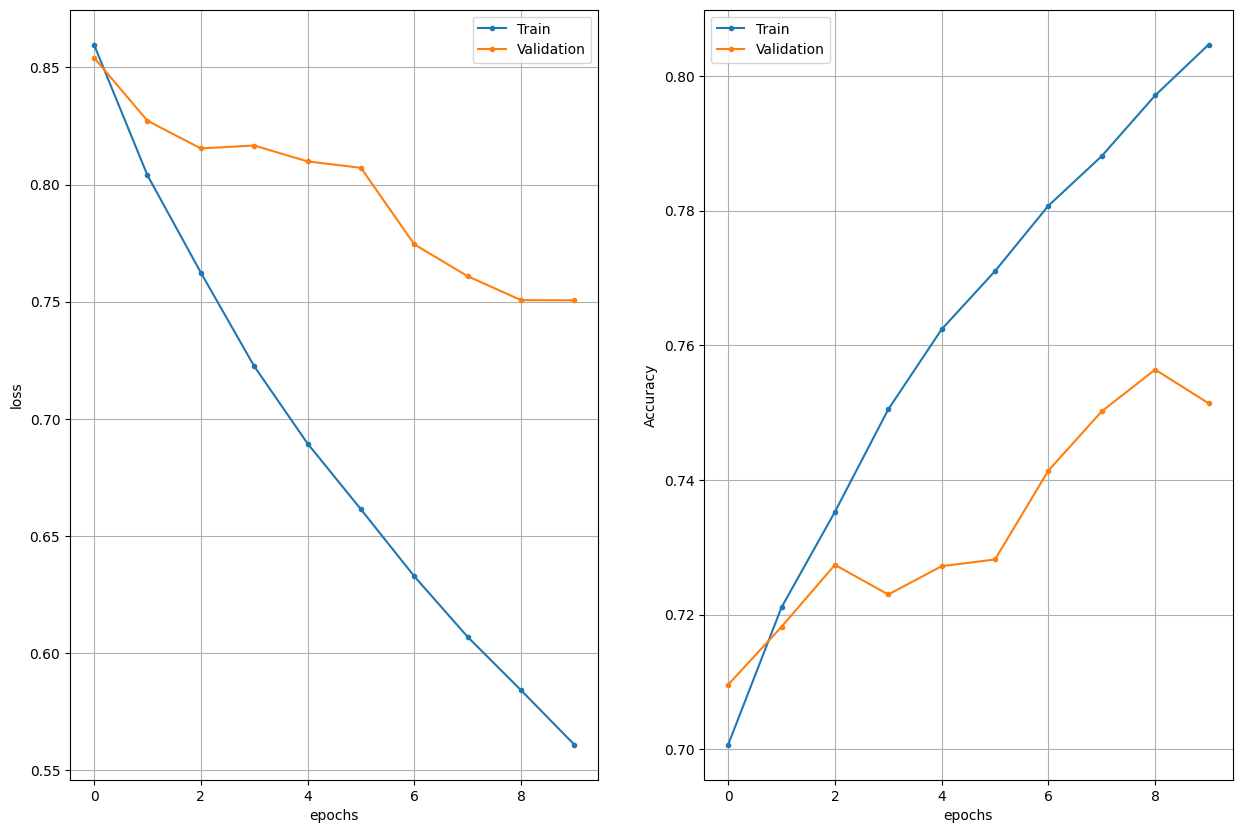

In [17]:
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])    

In [18]:
# Compute the labels and the predictions as sparse values
y_true = np.argmax(y_test, axis=1)
y_pred = model.predict(x_test)

print('True', y_true[0:5])
print('Pred', np.argmax(y_pred[0:5, :], axis=1))
print('Pred', y_pred[0:5, :])
print(y_pred.shape)

# Compute and print the accuracy for each class
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

for class_id, class_name in classes.items():
    idxs = np.where(y_true_classes == class_id)[0]
    acc = np.mean(y_pred_classes[idxs] == y_true_classes[idxs])
    print(class_name, acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step
True [3 8 8 0 6]
Pred [3 8 8 0 6]
Pred [[9.41064674e-03 6.07850542e-03 8.65100138e-03 8.76424551e-01
  1.14852528e-03 7.38166124e-02 1.10726263e-02 1.82862894e-03
  1.11907544e-02 3.78141005e-04]
 [2.56432197e-03 1.79341473e-02 3.91595040e-06 1.28471825e-07
  4.48995898e-08 1.65631819e-09 1.94343777e-08 2.77171708e-09
  9.79324877e-01 1.72565691e-04]
 [3.91422182e-01 4.67881784e-02 4.33274452e-03 2.45158933e-03
  1.52332534e-03 3.53756332e-04 2.13767897e-04 1.88401947e-03
  5.22010148e-01 2.90202666e-02]
 [8.11962426e-01 1.24762736e-01 4.89424802e-02 7.37208058e-04
  4.97216475e-04 1.41651412e-06 1.53145564e-07 3.65620799e-05
  1.29773738e-02 8.23934315e-05]
 [1.61124532e-07 3.49196671e-05 9.45967343e-03 2.49491408e-02
  1.12806737e-01 6.34989192e-05 8.52678955e-01 2.61453636e-07
  5.31681553e-06 1.33259914e-06]]
(10000, 10)
plane 0.761
car 0.897
bird 0.706
cat 0.463
deer 0.741
dog 0.668
frog 0.726
horse 0.783
ship 0.802
truck 0.814


In [19]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7355 - loss: 0.7822
Test loss   0.7823649644851685
Test metric 0.7361000180244446


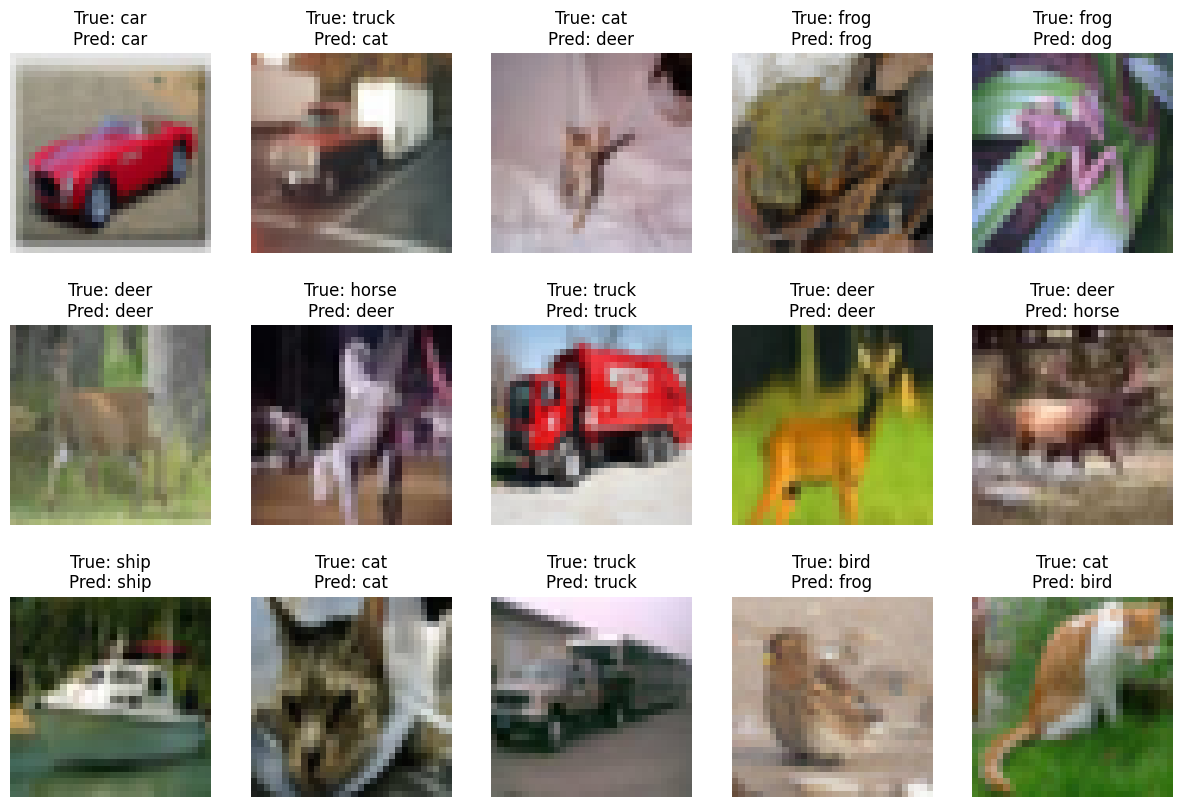

In [20]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = np.random.randint(0, len(x_test))
    # Show the results
    plt.subplot(3,5,ii+1)
    plt.imshow(x_test[idx, ...])
    plt.axis('off')
    plt.title(f"True: {classes[y_true_classes[idx]]}\nPred: {classes[y_pred_classes[idx]]}")